In [ ]:
!pip install osmnx contextily mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.0 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

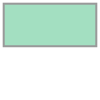

In [ ]:
# Центральная часть Санкт-Петербурга
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

polygon_wgs

In [ ]:
# TODO: загрузите граф дорожной сети
G = ox.graph_from_polygon(
    polygon_wgs,
    network_type="drive",
    simplify=True,
    retain_all=False
)

# TODO: получите GeoDataFrame узлов и рёбер
nodes, edges = ox.graph_to_gdfs(G)

print(edges.shape)
edges.head()

(16176, 15)


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (30.33142 59.89509, 30.33109 59.89526)   
       389449562  0    LINESTRING (30.33142 59.89509, 30.33182 59.89529)   
219811 1832085962 0      LINESTRING (30.33748 59.8993, 30.33793 59.8992)   
       1465050831 0    LINESTRING (30.33748 59.8993, 30.3372 59.89897...   
219812 249890545  0    LINESTRING (30.33955 59.90173, 30.33982 59.90146)   

                      bridge junction  ref width tunnel access  
u      v          key                                           
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN

In [ ]:
edges_m = edges.to_crs("EPSG:32636")
edges_m.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Функция для прямого расстояния между началом и концом LineString
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)  # евклидово расстояние

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость: отношение длины линии к прямому расстоянию
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги в радианах
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,183.554633,177.120246,1.045379,0.001167
std,243.995907,228.388397,0.896788,1.818570
min,1.236514,0.000000,1.000000,-3.141433
25%,28.296945,27.432919,1.000000,-1.582503
50%,106.825070,104.682539,1.000018,-0.000176
75%,248.837794,243.176946,1.002707,1.554398
max,6640.370574,5357.940848,76.797540,3.140873


In [ ]:
roads["highway_str"] = roads["highway"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))

# TODO: создайте dummy-переменные для highway_str
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")

roads = pd.concat([roads, highway_dummies], axis=1)

highway_dummies.head()

highway_living_street  highway_motorway  \
u      v          key                                            
219808 2327840    0                    False             False   
       389449562  0                    False             False   
219811 1832085962 0                    False             False   
       1465050831 0                    False             False   
219812 249890545  0                    False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_primary_link,primary  highway_residential  \
u      v          key                                                      
219808 2327840    0                           False                False   
       389449562  0                           False                False   
219811 1832085962 0                           False                False   
       1465050831 0                           False                False   
219812 249890545  0                           False                False   

                       highway_residential,living_street  \
u      v          key                                      
219808 2327840    0                                False   
       389449562  0                                False   
219811 1832085962 0                                False   
       1465050831 0                                False   
219812 249890545  0                                False   

                       highway_residential,primary_link  \
u      v          key                                     
219808 2327840    0                               False   
       389449562  0                               False   
219811 1832085962 0                               False   
       1465050831 0                               False   
219812 249890545  0                               False   

                       highway_residential,tertiary  \
u      v          key                                 
219808 2327840    0                           False   
       389449562  0                           False   
219811 1832085962 0                           False   
       1465050831 0                           False   
219812 249890545  0                           False   

                       highway_residential,unclassified  ...  \
u      v          key                                    ...   
219808 2327840    0                               False  ...   
       389449562  0                               False  ...   
219811 1832085962 0                               False  ...   
       1465050831 0                               False  ...   
219812 249890545  0                               False  ...   

                       highway_secondary_link  \
u      v          key                           
219808 2327840    0                     False   
       389449562  0                     False   
219811 1832085962 0                     False   
       1465050831 0                     False   
219812 249890545  0                     False   

                       highway_secondary_link,secondary  highway_tertiary  \
u      v          key                                                       
219808 2327840    0                               False             False   
       389449562  0                               False             False   
219811 1832085962 0                               False             False   
       1465050831 0                               False             False   
219812 249890545  0                               False             False   

                       h

In [ ]:
# Теги городских объектов
poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}

stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}

# TODO: загрузите POI и остановки через ox.features_from_polygon
pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print("POI:", pois.shape)
print("Stops:", stops.shape)

POI: (96944, 1227)
Stops: (7435, 124)


In [ ]:
def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    # Для полигонов representative_point часто лучше centroid: точка точно лежит внутри полигона
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

# TODO: примените функцию к pois и stops
pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

geometry         amenity  \
element id                                                          
node    29001764   POINT (346911.245 6645602.235)  ferry_terminal   
        248465159  POINT (355699.365 6655570.419)             NaN   
        248465166  POINT (355735.863 6655631.331)             NaN   
        248701411   POINT (354243.62 6655104.647)             NaN   
        249082841  POINT (349260.755 6647401.446)             NaN   

                          railway        contact:email  \
element id                                               
node    29001764   ferry_terminal                  NaN   
        248465159             NaN  fclub-spb@yandex.ru   
        248465166             NaN                  NaN   
        248701411             NaN                  NaN   
        249082841             NaN                  NaN   

                                   contact:phone       contact:website  \
element id                                                               
node    29001764                             NaN                   NaN   
        248465159  +7 812 2918980;+7 812 5908868  https://fclub-spb.ru   
        248465166                            NaN                   NaN   
        248701411                            NaN                   NaN   
        249082841                            NaN                   NaN   

                         leisure            name  \
element id                                         
node    29001764             NaN             NaN   
        248465159  sports_centre          Фитнес   
        248465166            NaN    Всё для дома   
        248701411            NaN             NaN   
        249082841            NaN  Петру Великому   

                                          opening_hours        shop  ...  \
element id                                                           ...   
node    29001764                                    NaN         NaN  ...   
        248465159  Mo-Fr 07:00-23:00; Sa-Su 09:00-22:00         NaN  ...   
        248465166                                   NaN         yes  ...   
        248701411                                   NaN  car_repair  ...   
        249082841                                   NaN         NaN  ...   

                  brand:wikipedia:ar brand:short canoe:type  \
element id                                                    
node    29001764                 NaN         NaN        NaN   
        248465159                NaN         NaN        NaN   
        248465166                NaN         NaN        NaN   
        248701411                NaN         NaN        NaN   
        249082841                NaN         NaN        NaN   

                  education_programme:FR ref:en ref:ru addr:housenumber2  \
element id                                                                 
node    29001764                     NaN    NaN    NaN               NaN   
        248465159                    NaN    NaN    NaN               NaN   
        248465166                    NaN    NaN    NaN               NaN   
        248701411                    NaN    NaN    NaN               NaN   
        249082841                    NaN    NaN    NaN               NaN   

                  blood:plasma blood:whole donation:compensation  
element id                                                        
node    29001764           NaN         NaN                   NaN  
        248465159          NaN         NaN                   NaN  
        248465166          NaN         NaN                   NaN  
        248701411          NaN         NaN                   NaN  
        249082841          NaN         NaN                   NaN  

[5 rows x 1227 columns]

In [ ]:
def nearest_and_count(source_gdf, target_gdf, radius=300):
    """
    source_gdf: объекты, для которых считаем признаки, например дороги
    target_gdf: объекты окружения, например POI или остановки
    radius: радиус поиска в метрах
    """
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    # TODO: расстояние до ближайшего объекта
    dist, ind = tree.query(source_coords, k=1)  # k=1
    nearest_dist = dist[:, 0]

    # TODO: количество объектов в радиусе
    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Для расчётов используем центроиды дорог как точки
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,49.583569,140.522997,143.417061,9.910423
std,57.391652,133.207079,145.281730,7.527159
min,0.293001,0.000000,0.160834,0.000000
25%,20.350445,47.000000,48.666572,4.000000
50%,34.839845,96.000000,103.713260,8.000000
75%,58.375453,197.000000,191.644245,14.000000
max,1095.915800,1003.000000,1695.642643,56.000000


In [ ]:
# В edges/roads индекс обычно MultiIndex: u, v, key
roads = roads.reset_index()

# TODO: словарь степеней узлов
node_degree = dict(G.degree())  # G

roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16176.000000,16176.000000,16176.000000
mean,4.424641,4.423405,4.424023
std,1.320487,1.322241,1.082633
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


In [ ]:
# Нормировка признаков в диапазон примерно 0..1

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"] = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

# TODO: придумайте веса компонентов
roads["traffic_load_score"] = (
    0.25 * roads["length_norm"] +
    0.20 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.15 * roads["near_poi_norm"] +
    0.10 * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

,traffic_load_score
count,16176.000000
mean,0.368477
std,0.090426
min,0.002053
25%,0.309570
50%,0.367963
75%,0.428260
max,0.802974


In [ ]:
base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

highway_features = list(highway_dummies.columns)

# TODO: объедините списки признаков
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

X.shape, y.shape

((16176, 32), (16176,))

In [ ]:
# TODO: используйте train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((12132, 32), (4044, 32))

In [ ]:
# !pip install lightgbm xgboost catboost

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Создаём модели
model_lgb = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_cat = CatBoostRegressor(iterations=100, random_seed=42, verbose=False)

# Обучение
print("Обучение LightGBM...")
model_lgb.fit(X_train, y_train)

print("Обучение XGBoost...")
model_xgb.fit(X_train, y_train)

print("Обучение CatBoost...")
model_cat.fit(X_train, y_train)

print("✅ Все модели обучены!")

ModuleNotFoundError: No module named 'catboost'

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.5 MB/s eta 0:00:00


In [ ]:
model_lgb = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_cat = CatBoostRegressor(iterations=100, random_seed=42, verbose=False)

print("Обучение LightGBM...")
model_lgb.fit(X_train, y_train)

print("Обучение XGBoost...")
model_xgb.fit(X_train, y_train)

print("Обучение CatBoost...")
model_cat.fit(X_train, y_train)

print("✅ Все модели обучены!")

NameError: name 'CatBoostRegressor' is not defined

In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

model_lgb = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

print("Обучение LightGBM...")
model_lgb.fit(X_train, y_train)

print("Обучение XGBoost...")
model_xgb.fit(X_train, y_train)

print("✅ Модели обучены!")

Обучение LightGBM...


LightGBMError: Do not support special JSON characters in feature name.

In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


X_train_clean = X_train.copy()
X_test_clean = X_test.copy()


X_train_clean.columns = [str(col).replace("[", "").replace("]", "").replace(",", "_") for col in X_train_clean.columns]
X_test_clean.columns = [str(col).replace("[", "").replace("]", "").replace(",", "_") for col in X_test_clean.columns]


model_lgb = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)


print("Обучение LightGBM...")
model_lgb.fit(X_train_clean, y_train)

print("Обучение XGBoost...")
model_xgb.fit(X_train_clean, y_train)

print("✅ Модели обучены!")

Обучение LightGBM...
Обучение XGBoost...
✅ Модели обучены!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


y_pred_lgb = model_lgb.predict(X_test_clean)
y_pred_xgb = model_xgb.predict(X_test_clean)

# Метрики для LightGBM
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

# Метрики для XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))


print("="*40)
print("LightGBM:")
print(f"  MAE:  {mae_lgb:.4f}")
print(f"  RMSE: {rmse_lgb:.4f}")

print("\n" + "="*40)
print("XGBoost:")
print(f"  MAE:  {mae_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")


print("\n" + "="*40)
if rmse_lgb < rmse_xgb:
    print(f"  Лучше LightGBM (RMSE ниже на {rmse_xgb - rmse_lgb:.4f})")
else:
    print(f"  Лучше XGBoost (RMSE ниже на {rmse_lgb - rmse_xgb:.4f})")

LightGBM:
  MAE:  0.0402
  RMSE: 0.0506

XGBoost:
  MAE:  0.0428
  RMSE: 0.0536

  Лучше LightGBM (RMSE ниже на 0.0031)


In [ ]:
print("Переменные, которые уже есть:")
for var in dir():
    if not var.startswith('_'):
        print(f"  - {var}")

Переменные, которые уже есть:
  - BallTree
  - ElasticNet
  - G
  - HistGradientBoostingRegressor
  - In
  - LGBMRegressor
  - Lasso
  - LinearRegression
  - Out
  - PolynomialFeatures
  - Ridge
  - StandardScaler
  - X
  - XGBRegressor
  - X_test
  - X_test_clean
  - X_train
  - X_train_clean
  - base_features
  - bbox
  - box
  - edges
  - edges_m
  - exit
  - feature_cols
  - get_ipython
  - gpd
  - highway_dummies
  - highway_features
  - mae_lgb
  - mae_xgb
  - mean_absolute_error
  - mean_squared_error
  - minmax
  - model_lgb
  - model_xgb
  - nearest_and_count
  - node_degree
  - nodes
  - noise
  - np
  - nx
  - ox
  - pd
  - permutation_importance
  - plt
  - poi_tags
  - pois
  - pois_m
  - polygon_wgs
  - quit
  - r2_score
  - rmse_lgb
  - rmse_xgb
  - rng
  - road_points
  - roads
  - scaler
  - segment_angle
  - sheets
  - stop_tags
  - stops
  - stops_m
  - straight_distance
  - to_points
  - train_test_split
  - warnings
  - y
  - y_pred_lgb
  - y_pred_xgb
  - y_test
  

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5)
}

print("=== Сравнение моделей ===\n")
best_model = None
best_rmse = float('inf')

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    print(f"{name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = name

print(f"\nЛучшая модель: {best_model} (RMSE = {best_rmse:.2f})")

print("\n=== Настройка гиперпараметров ===")

if best_model == 'Ridge (L2)':
    for alpha in [0.01, 0.1, 1, 10, 100]:
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        print(f"alpha = {alpha:6.2f} -> RMSE = {rmse:.2f}")

elif best_model == 'Lasso (L1)':
    for alpha in [0.0001, 0.001, 0.01, 0.1, 1]:
        model = Lasso(alpha=alpha, max_iter=5000)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        print(f"alpha = {alpha:.5f} -> RMSE = {rmse:.2f}")

elif best_model == 'ElasticNet':
    for alpha in [0.0001, 0.001, 0.01, 0.1]:
        for l1_ratio in [0.1, 0.5, 0.9]:
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000)
            model.fit(X_train_scaled, y_train)
            pred = model.predict(X_test_scaled)
            rmse = np.sqrt(mean_squared_error(y_test, pred))
            print(f"alpha = {alpha:.5f}, l1_ratio = {l1_ratio} -> RMSE = {rmse:.2f}")

else:
    print("LinearRegression не имеет гиперпараметров. Пробуем полиномы...")
    for degree in [1, 2, 3]:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        pred = model.predict(X_test_poly)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        print(f"Степень {degree} -> RMSE = {rmse:.2f}")

print("\nГотово!")

=== Сравнение моделей ===

LinearRegression: MAE = 0.04, RMSE = 0.05
Ridge (L2): MAE = 0.04, RMSE = 0.05
Lasso (L1): MAE = 0.04, RMSE = 0.05
ElasticNet: MAE = 0.04, RMSE = 0.05

Лучшая модель: Lasso (L1) (RMSE = 0.05)

=== Настройка гиперпараметров ===
alpha = 0.00010 -> RMSE = 0.05
alpha = 0.00100 -> RMSE = 0.05
alpha = 0.01000 -> RMSE = 0.06
alpha = 0.10000 -> RMSE = 0.09
alpha = 1.00000 -> RMSE = 0.09

Готово!
